# VGG19

Publikacje:
 - https://www.robots.ox.ac.uk/~vgg/publications/2015/Simonyan15/simonyan15.pdf?utm_source=chatgpt.com
 - https://www.researchgate.net/publication/346425175_Correlated_Time-Series_in_Multi-Day-Ahead_Streamflow_Forecasting_Using_Convolutional_Networks
 - https://ieeexplore.ieee.org/abstract/document/10551185
 - https://ieeexplore.ieee.org/document/10551185
 - Znaleźć coś o transfer learning

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.optim as optim
import torchvision.models as models
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, r2_score


## Data preparation

min: nan, max: nan
min RGB: nan, max RGB: nan
(128, 128, 3)
4.68


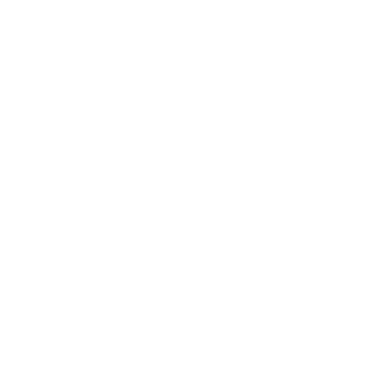

In [ ]:
df = pd.read_csv('df_final.csv')
row = df.iloc[1]

chunk = np.load(f'images/images_chunk_00{row['chunk_id']}.npy')
image = chunk[int(row['id_in_chunk'])]

rgb_image = image[:, :, 1:4]

rgb_image = rgb_image.astype('float32')
rgb_image = rgb_image / rgb_image.max() if rgb_image.max() > 0 else rgb_image
print(rgb_image.shape)
print(row['flow'])

plt.imshow(rgb_image)
plt.axis('off')
plt.show()

In [ ]:
# Cleaning null data
nan_indices = []

for idx in range(len(df)):
    row = df.iloc[idx]
    chunk = np.load(f'images/images_chunk_{int(row["chunk_id"]):03d}.npy', mmap_mode='r')
    image = chunk[int(row['id_in_chunk'])]
    if np.isnan(image).any():
        nan_indices.append(idx)

print(f"Obrazy z NaN: {len(nan_indices)} / {len(df)}")

Obrazy z NaN: 99 / 37092


### Split train/test sets

In [ ]:
df = pd.read_csv('df_final.csv')
df.head()

,date,flow,chunk_id,id_in_chunk
0,2015-08-10,0.09,0,343
1,2015-09-10,4.68,2,458
2,2015-08-10,0.22,3,318
3,2015-08-17,0.22,3,317
4,2015-11-25,1.12,1,364


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df = df.sort_values('date').reset_index(drop=True)

train_df = df[df['year'] <= 2020].reset_index(drop=True)
val_df = df[df['year'] == 2021].reset_index(drop=True)
test_df = df[df['year'] == 2022].reset_index(drop=True)

print('Train:', len(train_df))
print('Val:', len(val_df))
print('Test:', len(test_df))

Train: 25240
Val: 6408
Test: 5444


TO DO: split data based on station_id (train based on one group of stations, tets on the other one)

In [ ]:
chunk = np.load('images/images_chunk_000.npy')

print(chunk.shape)
print(chunk.dtype)
print(chunk.min(), chunk.max())

(500, 128, 128, 4)
float32
0.0 1.0


### Transform data


In [21]:
import torchvision.transforms as transforms
MEAN = [0.485, 0.456, 0.406] # Data ImageNet
STD  = [0.229, 0.224, 0.225]

vgg19_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(
        mean=MEAN,
        std=STD
    )
])

In [ ]:
def transform_images(image):
    rgb_image = image[:, :, 1:4]
    rgb_image = rgb_image.astype('float32')
     
    p2  = np.percentile(rgb_image, 2)
    p98 = np.percentile(rgb_image, 98)
    rgb_image = np.clip(rgb_image, p2, p98)
    rgb_image = (rgb_image - p2) / (p98 - p2 + 1e-8) 
    
    x = np.transpose(rgb_image, (2, 0, 1))
    x = torch.tensor(x, dtype=torch.float32)
    x = vgg19_transform(x)
    return x

In [23]:
row = df.iloc[0]
chunk_id = int(row['chunk_id'])
id_in_chunk = int(row['id_in_chunk'])
    
chunk = np.load(f'images/images_chunk_{chunk_id:03d}.npy')
x = transform_images(chunk[0])
print(x.shape)

torch.Size([3, 224, 224])


In [ ]:
class RiverFlowDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self._chunk_cache = {}
    
    def __len__(self):
        return len(self.df)
    
    def load_chunk(self, chunk_id):
        if chunk_id not in self._chunk_cache:
            self._chunk_cache[chunk_id] = np.load(
                f'images/images_chunk_{chunk_id:03d}.npy',
                mmap_mode='r'
            )
        return self._chunk_cache[chunk_id]

    def __getitem__(self, idx):
        df_row = self.df.iloc[idx]
        chunk_id = int(df_row['chunk_id'])
        id_in_chunk = int(df_row['id_in_chunk'])

        chunk = self.load_chunk(chunk_id)
        image = chunk[id_in_chunk]

        x = transform_images(image)
        y = torch.tensor(np.log1p(df_row['flow']), dtype=torch.float32)
        return x, y
    

In [ ]:
train_loader = DataLoader(RiverFlowDataset(train_df), batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(RiverFlowDataset(val_df),   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(RiverFlowDataset(test_df),  batch_size=16, shuffle=False, num_workers=2)

In [ ]:
images, flows = next(iter(train_loader))

print(images.shape)
print(flows.shape)

In [ ]:
# TO DO:
def compute_stats(df, num_samples=5000):
    sample = df.sample(min(num_samples, len(df)), random_state=42)
    pixels = []
    chunk_cache = {}

    for _, row in sample.iterrows():
        chunk_id    = int(row['chunk_id'])
        id_in_chunk = int(row['id_in_chunk'])

        if chunk_id not in chunk_cache:
            chunk_cache[chunk_id] = np.load(
                f'images/images_chunk_{chunk_id:03d}.npy',
                mmap_mode='r'
            )

        image = chunk_cache[chunk_id][id_in_chunk]
        rgb   = image[:, :, 1:4].astype('float32')

        p2  = np.percentile(rgb, 2)
        p98 = np.percentile(rgb, 98)
        rgb = np.clip(rgb, p2, p98)
        rgb = (rgb - p2) / (p98 - p2 + 1e-8)

        pixels.append(rgb.reshape(-1, 3))

    pixels = np.concatenate(pixels, axis=0)
    mean   = pixels.mean(axis=0).tolist()
    std    = pixels.std(axis=0).tolist()
    print(f'MEAN = {mean}')
    print(f'STD  = {std}')
    return mean, std

# Uruchom i wstaw wyniki do MEAN/STD
MEAN, STD = compute_stats(train_df)

## Model

In [ ]:
print('cuda' if torch.cuda.is_available() else 'cpu')

cpu


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgg19 = models.vgg19(weights='IMAGENET1K_V1')


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\epaw0/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:47<00:00, 12.1MB/s] 


In [ ]:
for param in vgg19.features.parameters(): #zamrozenie
        param.requires_grad = False

vgg19.classifier[6] = nn.Linear(4096, 1)
model = vgg19.to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)
num_epochs = 15
losses=[]
val_losses=[]
best_val_loss = float('inf')
patience = 5
epochs_without_improve = 0

In [ ]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_id, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        prediction = model(x).squeeze(1)
        loss = criterion(prediction, y)

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)
    losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_prediction = model(x).squeeze(1)
            loss = criterion(val_prediction, y)
            val_loss += loss.item() * x.size(0)
        
        val_loss /=len(val_loader.dataset)
        val_losses.append(val_loss)
    print(f'Epoch {epoch+1:02d}')
    print(f'Train_loss: {train_loss:.4f}')
    print(f'Val_loss: {val_loss:.4f}')

    if val_loss > best_val_loss:
        epochs_without_improve += 1
        print(f'No improvement - {epochs_without_improve}/{patience}')
        if epochs_without_improve >= patience:
            print('Early stopping.')
            break
    else:
        best_val_loss= val_loss
        epochs_without_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))

In [ ]:
plt.plot(range(1, num_epochs + 1), losses, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation loss')

plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
plt.plot(x=range(1, num_epochs + 1), y=losses)
plt.title('Train loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.show()

In [ ]:
plt.plot(x=range(1, num_epochs + 1), y=val_losses)
plt.title('Validation loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Val loss')
plt.show()

## Evaluation

In [ ]:
model.eval()

pred_y =[]
true_y =[]

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        prediction = model(x).squeeze(1)
        
        pred_y.append(prediction.cpu().numpy())
        true_y.append(y.cpu().numpy())

all_preds =  np.concatenate(pred_y)
all_trues = np.concatenate(true_y)

all_true_y   = np.expm1(all_trues)
all_pred_y = np.expm1(all_preds)
   
mae = mean_absolute_error(all_true_y, all_pred_y)
rmse = np.sqrt(np.mean((all_true_y - all_pred_y) ** 2))
r2 = r2_score(all_true_y, all_pred_y)

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(all_true_y, all_pred_y, alpha=0.5)
plt.title('Predicted vs True Flow')
plt.xlabel('True flow')
plt.ylabel('Predicted flow')
plt.show()

In [ ]:
n = 100  
plt.figure(figsize=(12, 4))
plt.plot(all_true_y[:n], label='True flow')
plt.plot(all_pred_y[:n], label='Predicted flow')
plt.xlabel('Sample')
plt.ylabel('Flow')
plt.title('Predicted vs True Flow')
plt.legend()
plt.show()

In [ ]:
residuals = all_pred_y - all_true_y
plt.scatter(all_true_y, residuals, alpha=0.3, s=15, color='steelblue')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.title('Residuals')
plt.xlabel('True flow')
plt.ylabel('Resiudals')
plt.show()

## Features indetification